# Benchmark Comparison: H-Net vs SmilesPE

**Research Question (d):** How does this deep-learnt dynamic tokeniser result in different tokens compared to the benchmark using SmilesPE tokenizer?

## Comparisons

We'll compare each of the 6 H-Net models against SmilesPE on their respective datasets:
- All PI1M models vs SmilesPE on PI1M dataset
- All MOSES models vs SmilesPE on MOSES dataset

## Analysis Goals
1. Compare token distributions between H-Net and SmilesPE
2. Analyze differences in token lengths
3. Compare top tokens and breakpoint preferences
4. Quantify chemical validity patterns


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("talk")
colors = sns.color_palette("mako", 10)
plt.rcParams['figure.figsize'] = (14, 8)

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

from analysis.utils.statistics import TokenStatistics, compare_token_distributions, create_comparison_dataframe

# Load all H-Net statistics
stats_dir = project_root / 'analysis' / 'data' / 'statistics'

hnet_stats = {
    'PI1M_concat_1epoch': TokenStatistics.load(str(stats_dir / 'PI1M_concat_1epoch_stats.json')),
    'PI1M_noconcat_5epoch': TokenStatistics.load(str(stats_dir / 'PI1M_noconcat_5epoch_stats.json')),
    'PI1M_concat_5epoch': TokenStatistics.load(str(stats_dir / 'PI1M_concat_5epoch_stats.json')),
    'PI1M_concat_22epoch': TokenStatistics.load(str(stats_dir / 'PI1M_concat_22epoch_stats.json')),
    'MOSES_noconcat_5epoch': TokenStatistics.load(str(stats_dir / 'MOSES_noconcat_5epoch_stats.json')),
    'MOSES_concat_5epoch': TokenStatistics.load(str(stats_dir / 'MOSES_concat_5epoch_stats.json')),
}

# Load SmilesPE benchmarks
spe_stats = {
    'SmilesPE_PI1M': TokenStatistics.load(str(stats_dir / 'SmilesPE_PI1M_stats.json')),
    'SmilesPE_MOSES': TokenStatistics.load(str(stats_dir / 'SmilesPE_MOSES_stats.json')),
}

print("✓ All statistics loaded!")


/opt/pytorch/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


✓ All statistics loaded!


## 1. Overall Comparison Table

Compare all models including SmilesPE benchmark.


In [2]:
# Combine all statistics
all_stats = {**hnet_stats, **spe_stats}

# Create comparison dataframe
comparison_df = create_comparison_dataframe(all_stats)

print("="*80)
print("Comprehensive Model Comparison (H-Net vs SmilesPE)")
print("="*80)
print(comparison_df.to_string(index=False))

# Save to file
comparison_df.to_csv(project_root / 'analysis' / 'data' / 'all_models_comparison.csv', index=False)
print("\n✓ Comparison table saved")


Comprehensive Model Comparison (H-Net vs SmilesPE)
                Model  Total Tokens  Unique Tokens  Total SMILES Avg Tokens/SMILES Median Tokens/SMILES Mean Token Length Median Token Length Std Token Length
   PI1M_concat_1epoch        216277           4903         10000             21.63                18.00              2.20                2.00             1.97
 PI1M_noconcat_5epoch        220423           4094         10000             22.04                20.00              2.16                1.00             1.81
   PI1M_concat_5epoch        182298           5775         10000             18.23                16.00              2.62                2.00             2.36
  PI1M_concat_22epoch        165928           8019         10000             16.59                15.00              2.87                2.00             2.79
MOSES_noconcat_5epoch        184614           3112         10000             18.46                18.00              1.88                1.00             

## 2. PI1M Models vs SmilesPE

Compare all PI1M H-Net models against SmilesPE baseline.


In [3]:
print("\n" + "="*60)
print("PI1M Models vs SmilesPE")
print("="*60)

pi1m_models = ['PI1M_concat_1epoch', 'PI1M_noconcat_5epoch', 'PI1M_concat_5epoch', 'PI1M_concat_22epoch']

for model_name in pi1m_models:
    comparison = compare_token_distributions(
        hnet_stats[model_name], spe_stats['SmilesPE_PI1M'],
        label1=model_name, label2="SmilesPE"
    )
    
    print(f"\n{model_name}:")
    print(f"  Token Jaccard: {comparison['token_overlap']['jaccard_similarity']:.4f}")
    print(f"  Breakpoint Jaccard: {comparison['breakpoint_overlap']['jaccard_similarity']:.4f}")
    print(f"  Mean Length Diff: {comparison['length_comparison']['mean_diff']:.4f}")



PI1M Models vs SmilesPE

PI1M_concat_1epoch:
  Token Jaccard: 0.1236
  Breakpoint Jaccard: 0.6818
  Mean Length Diff: 1.9965

PI1M_noconcat_5epoch:
  Token Jaccard: 0.1494
  Breakpoint Jaccard: 0.7317
  Mean Length Diff: 2.0380

PI1M_concat_5epoch:
  Token Jaccard: 0.0989
  Breakpoint Jaccard: 0.7895
  Mean Length Diff: 1.5856

PI1M_concat_22epoch:
  Token Jaccard: 0.1628
  Breakpoint Jaccard: 0.6818
  Mean Length Diff: 1.3275


## 3. MOSES Models vs SmilesPE

Compare all MOSES H-Net models against SmilesPE baseline.


In [4]:
print("\n" + "="*60)
print("MOSES Models vs SmilesPE")
print("="*60)

moses_models = ['MOSES_noconcat_5epoch', 'MOSES_concat_5epoch']

for model_name in moses_models:
    comparison = compare_token_distributions(
        hnet_stats[model_name], spe_stats['SmilesPE_MOSES'],
        label1=model_name, label2="SmilesPE"
    )
    
    print(f"\n{model_name}:")
    print(f"  Token Jaccard: {comparison['token_overlap']['jaccard_similarity']:.4f}")
    print(f"  Breakpoint Jaccard: {comparison['breakpoint_overlap']['jaccard_similarity']:.4f}")
    print(f"  Mean Length Diff: {comparison['length_comparison']['mean_diff']:.4f}")



MOSES Models vs SmilesPE

MOSES_noconcat_5epoch:
  Token Jaccard: 0.0753
  Breakpoint Jaccard: 0.8800
  Mean Length Diff: 4.0540

MOSES_concat_5epoch:
  Token Jaccard: 0.0753
  Breakpoint Jaccard: 0.8400
  Mean Length Diff: 3.9271


## 4. Visualization: Token Length Comparison


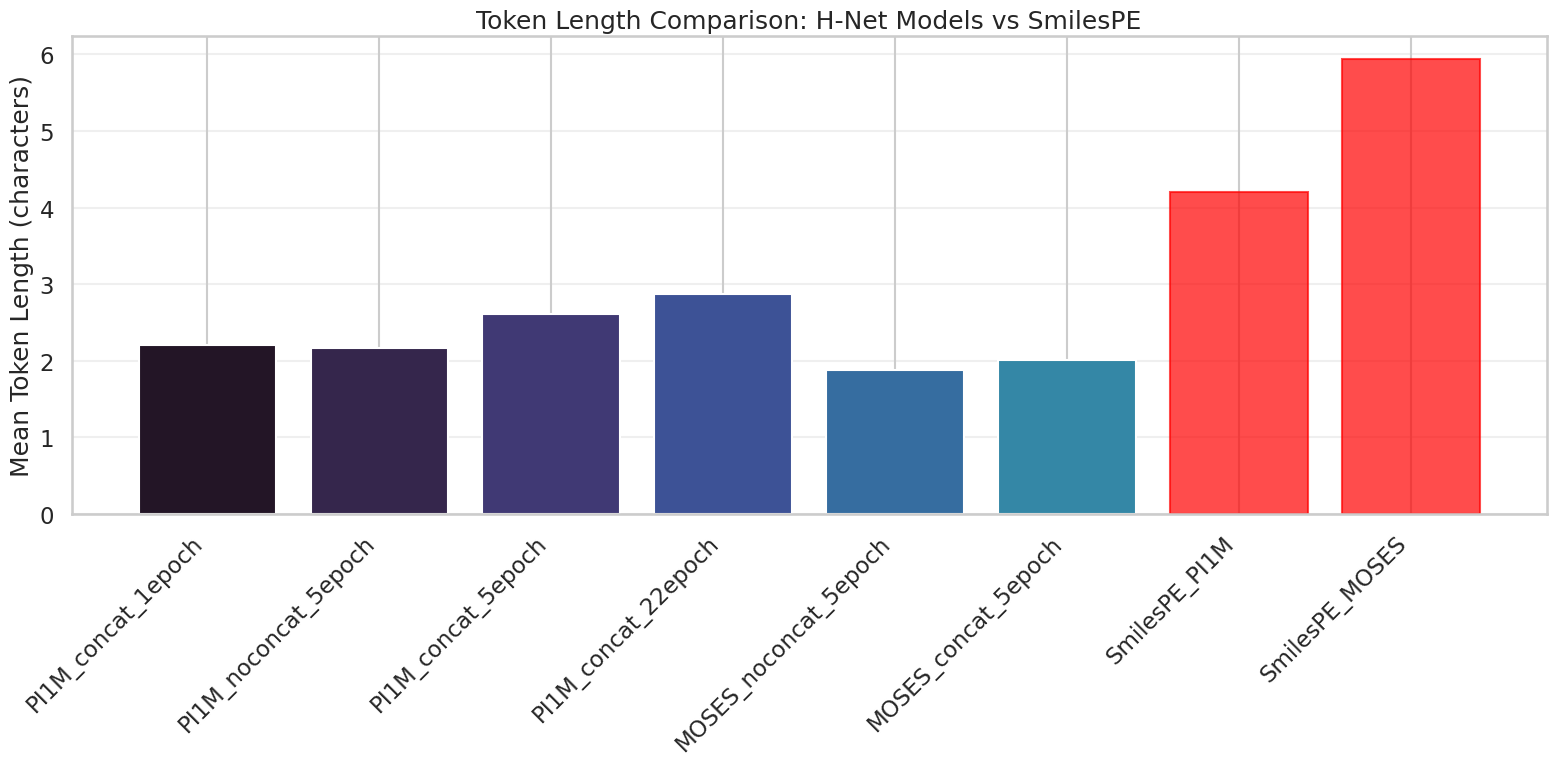


✓ Analysis complete!


In [5]:
# Extract mean token lengths for all models
model_names = []
mean_lengths = []

for name, stats in all_stats.items():
    summary = stats.get_summary()
    length_stats = summary['token_length_stats']
    model_names.append(name)
    mean_lengths.append(length_stats.get('mean', 0))

# Create bar plot
fig, ax = plt.subplots(figsize=(16, 8))
bars = ax.bar(range(len(model_names)), mean_lengths, color=colors[:len(model_names)])

# Highlight SmilesPE bars
for i, name in enumerate(model_names):
    if 'SmilesPE' in name:
        bars[i].set_color('red')
        bars[i].set_alpha(0.7)

ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.set_ylabel('Mean Token Length (characters)')
ax.set_title('Token Length Comparison: H-Net Models vs SmilesPE')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(project_root / 'analysis' / 'figures' / 'benchmark_token_lengths.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Analysis complete!")
